In [73]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
import logging

import matplotlib.pyplot as plt  # type: ignore
import numpy as np

import healpy as hp

from mlpng import Core
from mlpng.utils import (
    setup_logging,
    plot_cl_alm,
    plot_predictions,
    plot_histogram,
    plot_elsner_comp,
    pol_str,
)
from mlpng.generator import generate_alm, generate_alm_nl, lens_alms
from mlpng.utils.utils import print_errors

logger = setup_logging(__name__, level=logging.DEBUG)

mpi_comm = None

## Elsner test

This downloads the elsner sims and prints them out as a test comparison for the linear and non-linear alms.

To download uncomment the first cell, the second cell will just plot the sims. You only need the first sim if it is taking a long time.

In [75]:
# import requests

# for num in range(1, 1001):
#     URL1 = (
#         "https://dc.zah.uni-heidelberg.de/elsnersim/q/s/static/alm_l_"
#         + str(num).zfill(4)
#         + "_v3.fits"
#     )
#     URL2 = (
#         "https://dc.zah.uni-heidelberg.de/elsnersim/q/s/static/alm_nl_"
#         + str(num).zfill(4)
#         + "_v3.fits"
#     )

#     file1 = "data/elsner/alm_l_" + str(num).zfill(4) + "_v3.fits"
#     if not os.path.exists(file1):
#         with requests.Session() as s, open(file1, "wb") as f:
#             f.write(s.get(URL1).content)

#     file2 = "data/elsner/alm_nl_" + str(num).zfill(4) + "_v3.fits"
#     if not os.path.exists(file2):
#         with requests.Session() as s, open(file2, "wb") as f:
#             f.write(s.get(URL2).content)

#     print(f"Finished {num}")

In [76]:
# core = Core(
#     [
#         "settings/elsner.json",
#         "--nsims",
#         "1",
#         "--narray",
#         "1",
#         "--fnl_range",
#         "-100",
#         "100",
#         "--pols",
#         "T",
#     ]
# )

In [77]:
# core.init_estimator(verbose=True)

In [78]:
# idx = str(1).zfill(4)
# base1 = f"data/elsner/alm_l_{idx}_v3.fits"
# base2 = f"data/elsner/alm_nl_{idx}_v3.fits"

# # these load the TT, EE, TE alms
# alm_elsner_l = np.array(hp.read_alm(base1, hdu=(1, 2, 3)))
# alm_elsner_nl = np.array(hp.read_alm(base2, hdu=(1, 2, 3)))

# t_scale = core.cosmo.camb_params.TCMB * 1e6
# alm_elsner_l *= t_scale
# alm_elsner_nl *= t_scale

In [79]:
# def icov_func(alm):
#     ret = np.zeros_like(alm)
#     for pol in range(np.shape(alm)[0]):
#         # we drop
#         ret[pol] = hp.almxfl(alm[pol], core.icov[pol])
#     return ret

In [80]:
# theta_batch = int(np.floor(1.5 * core.lmax + 1)) // core.n_cpus

# fisher = 0
# if core.force_ksw:
#     if os.path.exists(core.mc_file):
#         logger.info("Loading KSW state from %s", core.mc_file)
#         core.estimator.start_from_read_state(core.mc_file)
#     else:
#         alm_steps = generate_alm(core, 100)
#         logger.debug("Done")

#         def step_loader(idx):
#             """for stepping the KSW estimator, we just generate new unique sims"""
#             logger.debug("Sending alm step %s", idx)
#             return alm_steps[idx, : core.npols]

#         logger.info("Running KSW step, num steps: %s", 100)
#         core.estimator.step_batch(step_loader, range(100), theta_batch=theta_batch)

#         # save the mc state if we are using the mc file
#         if True:
#             logger.info("Saving KSW state to %s", core.mc_file)
#             core.estimator.write_state(core.mc_file)

# else:
#     fisher = core.estimator.compute_fisher_isotropic(core.icov)
# print(f"Fisher: {fisher}, standard deviation: {1 / np.sqrt(fisher)}")

In [81]:
# pbar = tqdm(total=core.nsims, desc="Computing estimates")

# idxs = range(1, core.nsims + 1)
# fnls = core.rng.uniform(core.fnl_min, core.fnl_max, (core.nsims,))


# def icov_func(alm):
#     ret = np.zeros_like(alm)
#     for pol in range(core.npols):
#         ret[pol] = hp.almxfl(alm[pol], core.icov[pol])
#     return ret


# def alm_loader(i):
#     idx = str(i).zfill(4)
#     base1 = f"data/elsner/alm_l_{idx}_v3.fits"
#     base2 = f"data/elsner/alm_nl_{idx}_v3.fits"

#     # these load the TT, EE, TE alms
#     l = np.array(hp.read_alm(base1, (1, 2)))[core.pol_idxs()]
#     nl = np.array(hp.read_alm(base2, (1, 2)))[core.pol_idxs()]

#     alms = (l + fnls[i - 1] * nl) * t_scale

#     # need sto trim the values if we are using a lower lmax, throw error if asking for higher lmax
#     lmax = hp.Alm.getlmax(alms.shape[-1])
#     if lmax < core.lmax:
#         # this could be done earlyer but this is just test code so not super important to optimize
#         raise ValueError(
#             "alm has lmax %s < %s which cannot be resolved", lmax, core.lmax
#         )
#     if lmax > core.lmax:
#         # logger.debug("Trimming alm from lmax %s to %s", lmax, core.lmax)
#         alms = trim_alms(alms, core.lmax)
#     pbar.update(1)
#     return alms


# # icov_alms = [icov_func(alm_loader(i)) for i in idxs]
# estimates, _, _, _ = core.estimator.compute_estimate_batch(
#     lambda i: icov_func(alm_loader(i)),
#     idxs,
#     theta_batch=theta_batch,
#     fisher=fisher,
#     lin_term=0,
# )
# pbar.close()

In [82]:
# print_errors(fnls, estimates, fisher)
# plot_predictions(fnls, estimates, fisher=fisher, show=True)
# plot_histogram(fnls, estimates, show=True)

## Setup

In [83]:
core = Core(
    [
        "settings/n32.json",
        "--nsims",
        "100",
        "--narray",
        "1",
        "--fnl_range",
        "-100",
        "100",
        "--pols",
        "TE",
        # "--no-noise",
        # "--nside",
        # "128",
        # "--lmax",
        # "383",
    ]
)

16-Jan-25 19:08:53 - mlpng.core - INFO - Parsing CLI args: ['settings/n32.json', '--nsims', '100', '--narray', '1', '--fnl_range', '-100', '100', '--pols', 'TE']
16-Jan-25 19:08:53 - mlpng.core - INFO - Loading settings from file 'settings/n32.json'
16-Jan-25 19:08:53 - mlpng.core - DEBUG - Forcing setting 'nsims' to 100 due to CLI
16-Jan-25 19:08:53 - mlpng.core - DEBUG - Forcing setting 'narray' to 1 due to CLI
16-Jan-25 19:08:53 - mlpng.core - DEBUG - Forcing setting 'fnl_range' to [-100.0, 100.0] due to CLI
16-Jan-25 19:08:53 - mlpng.core - DEBUG - Forcing setting 'pols' to ['TE'] due to CLI
16-Jan-25 19:08:53 - mlpng.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 67.4, 'As': 2.457e-09, 'ns': 0.9649, 'ombh2': 0.0224, 'omch2': 0.12, 'tau': 0.054} (default: {'As': 2.13e-09, 'ns': 0.9624, 'pivot_scalar': 0.05})
16-Jan-25 19:08:53 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.457e-09
16-Jan-25 19:08:53 - mlpng.core - DEBUG - Overriding cosmo p

In [84]:
core.init_estimator(verbose=False)

icov [[0. 0.]
 [0. 0.]]
icov2 [[0. 0.]
 [0. 0.]]


## Alm

This code generates the alms

$$a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}^{NG}$$
with
$$a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]$$
and
$$\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)$$
$$\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)$$
$$B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}$$
where $\Delta_\phi$ is primordial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions   

In [85]:
alm_l = generate_alm(core)
alm_l[:, :, :2] = 0
alm_l[:, :, 96] = 0
alm_ng = generate_alm_nl(core, alm_l)

16-Jan-25 19:08:59 - mlpng.generator - DEBUG - Using pol_idxs: [0 1]
16-Jan-25 19:09:04 - mlpng.generator - DEBUG - Using temp folder for alm_nl generation: /lustre/scratch/client/users/stevensonb
16-Jan-25 19:09:04 - mlpng.generator - DEBUG - Starting...


alm_nl:   0%|          | 0/100 [00:00<?, ?it/s]

In [86]:
fnls = core.rng.uniform(core.fnl_min, core.fnl_max, (core.nsims, core.ndups, 1, 1))
alms = alm_l[:, None, core.pol_idxs()] + fnls * alm_ng[:, None]

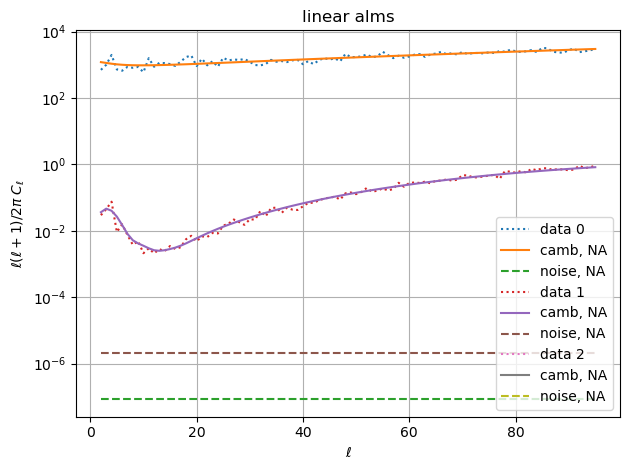

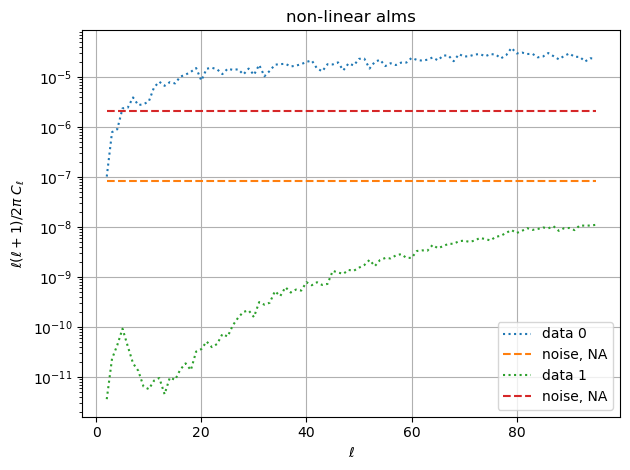

In [87]:
plot_cl_alm(
    core,
    alm_l[0],
    title="linear alms",
    # labels=plt_labels,
    plot_camb=True,
    plot_noise=True,
    plot_full_camb=False,
    show=True,
)

plot_cl_alm(
    core,
    alm_ng[0],
    title="non-linear alms",
    plot_camb=False,
    plot_noise=True,
    plot_full_camb=False,
    show=True,
)

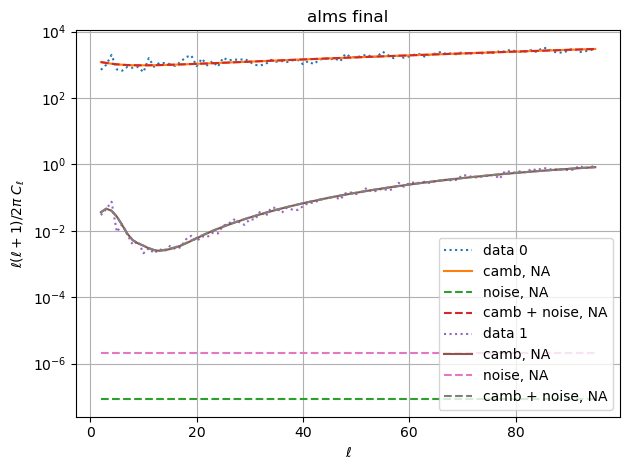

In [88]:
plot_cl_alm(
    core,
    alms[0, 0],
    title="alms final",
    plot_camb=True,
    plot_noise=True,
    plot_full_camb=True,
    show=True,
)

16-Jan-25 19:09:47 - mlpng.utils.plots - INFO - Mean ratio of alm NA: 15444.942693067325
16-Jan-25 19:09:47 - mlpng.utils.plots - INFO - Mean ratio of alm NA: 18076.276947248323
16-Jan-25 19:09:47 - mlpng.utils.plots - INFO - Mean ratio of elsner NA: 13309.537932821646
16-Jan-25 19:09:47 - mlpng.utils.plots - INFO - Mean ratio of elsner NA: 16407.04768286762


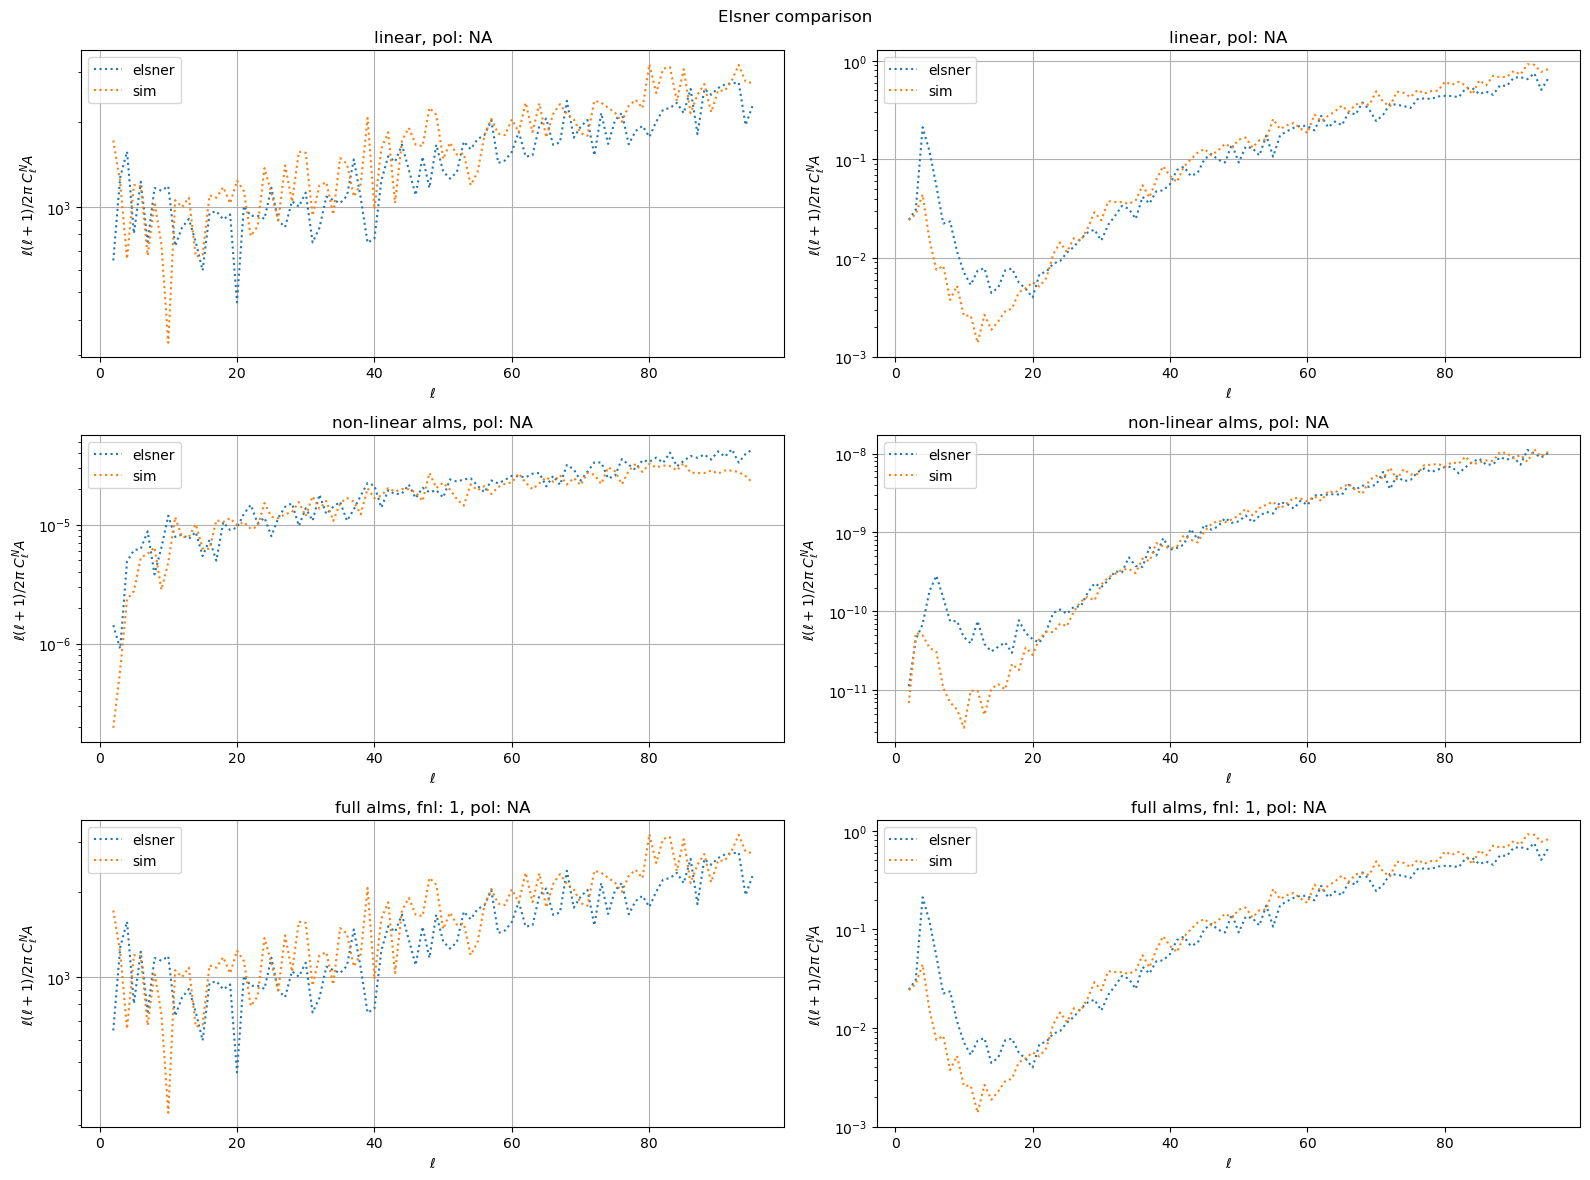

16-Jan-25 19:09:48 - mlpng.utils.plots - INFO - Mean ratio of alm NA: 15444.942693067325
16-Jan-25 19:09:48 - mlpng.utils.plots - INFO - Mean ratio of alm NA: 18076.276947248323
16-Jan-25 19:09:49 - mlpng.utils.plots - INFO - Mean ratio of elsner NA: 13309.537932821646
16-Jan-25 19:09:49 - mlpng.utils.plots - INFO - Mean ratio of elsner NA: 16407.04768286762


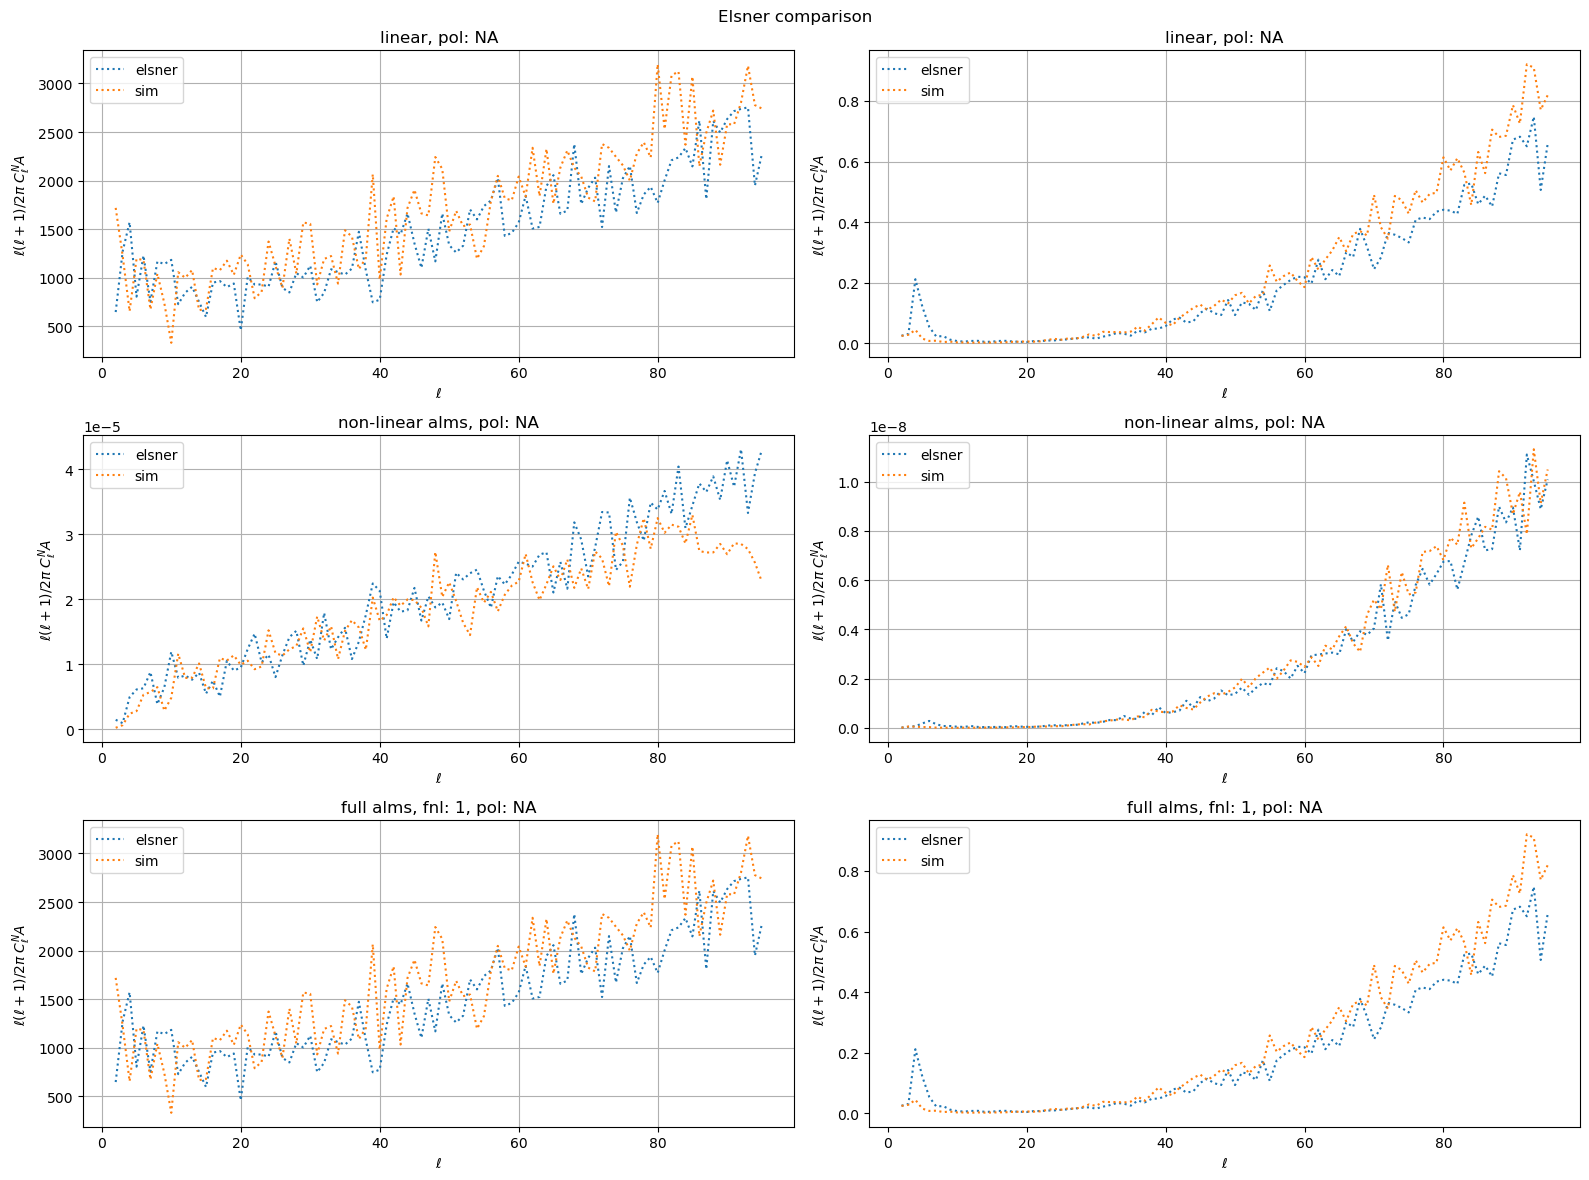

16-Jan-25 19:09:50 - mlpng.utils.plots - INFO - Mean ratio of alm NA: 15444.942693067325
16-Jan-25 19:09:50 - mlpng.utils.plots - INFO - Mean ratio of alm NA: 18076.276947248323
16-Jan-25 19:09:50 - mlpng.utils.plots - INFO - Mean ratio of elsner NA: 13309.537932821646
16-Jan-25 19:09:50 - mlpng.utils.plots - INFO - Mean ratio of elsner NA: 16407.04768286762


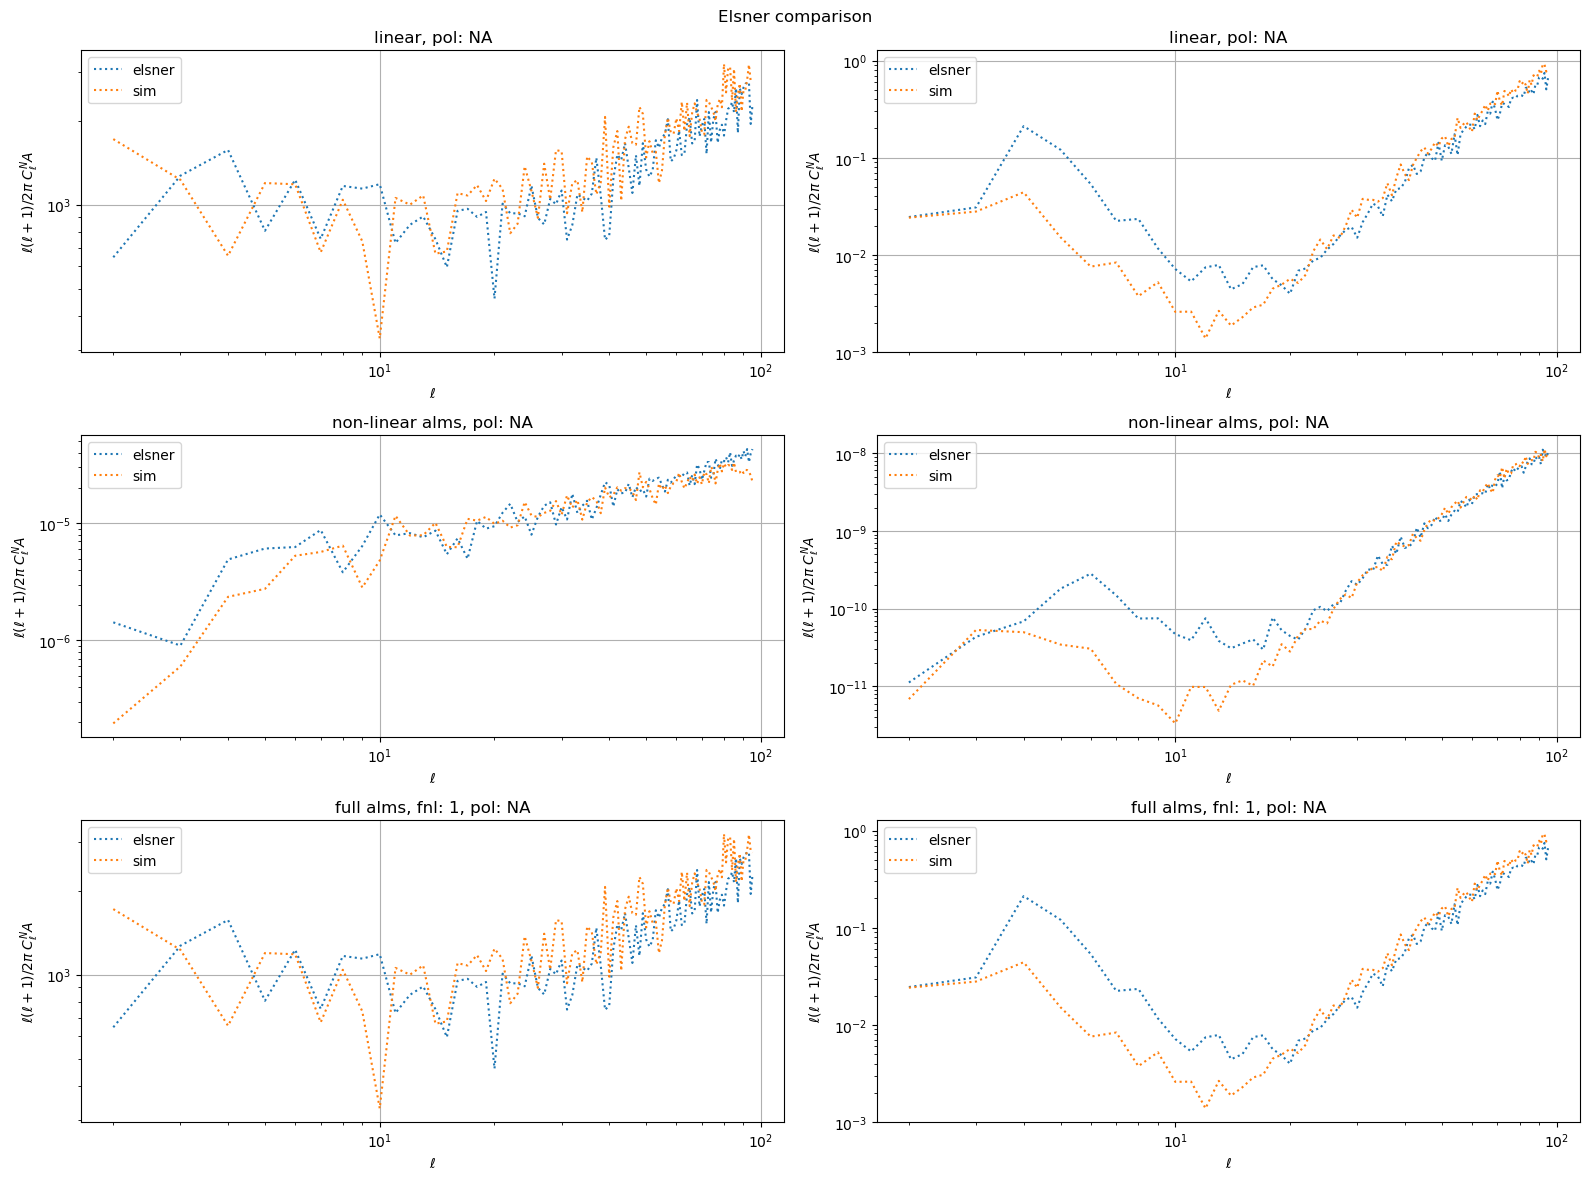

In [89]:
sim = core.rng.integers(core.nsims)
eidx = core.rng.integers(1, 1001)
plot_elsner_comp(
    core,
    alm_l[sim, core.pol_idxs()],
    alm_ng[sim],
    index=eidx,
    show=True,
    elsner_pols=core.pol_idxs(),
)
plot_elsner_comp(
    core,
    alm_l[sim, core.pol_idxs()],
    alm_ng[sim],
    index=eidx,
    show=True,
    plot_func=plt.plot,
    elsner_pols=core.pol_idxs(),
)
plot_elsner_comp(
    core,
    alm_l[sim, core.pol_idxs()],
    alm_ng[sim],
    index=eidx,
    show=True,
    elsner_pols=core.pol_idxs(),
    plot_func=plt.loglog,
)

16-Jan-25 19:09:53 - mlpng.utils.plots - DEBUG - Averaging 100 elsner sims, this will take a while


Averaging elsner sims:   0%|          | 0/100 [00:00<?, ?it/s]

16-Jan-25 19:10:05 - mlpng.utils.plots - INFO - Mean ratio of alm NA: 14948.282173739706
16-Jan-25 19:10:05 - mlpng.utils.plots - INFO - Mean ratio of alm NA: 14476.908939931362
16-Jan-25 19:10:05 - mlpng.utils.plots - INFO - Mean ratio of elsner NA: 13780.669249457596
16-Jan-25 19:10:05 - mlpng.utils.plots - INFO - Mean ratio of elsner NA: 14480.579420731705


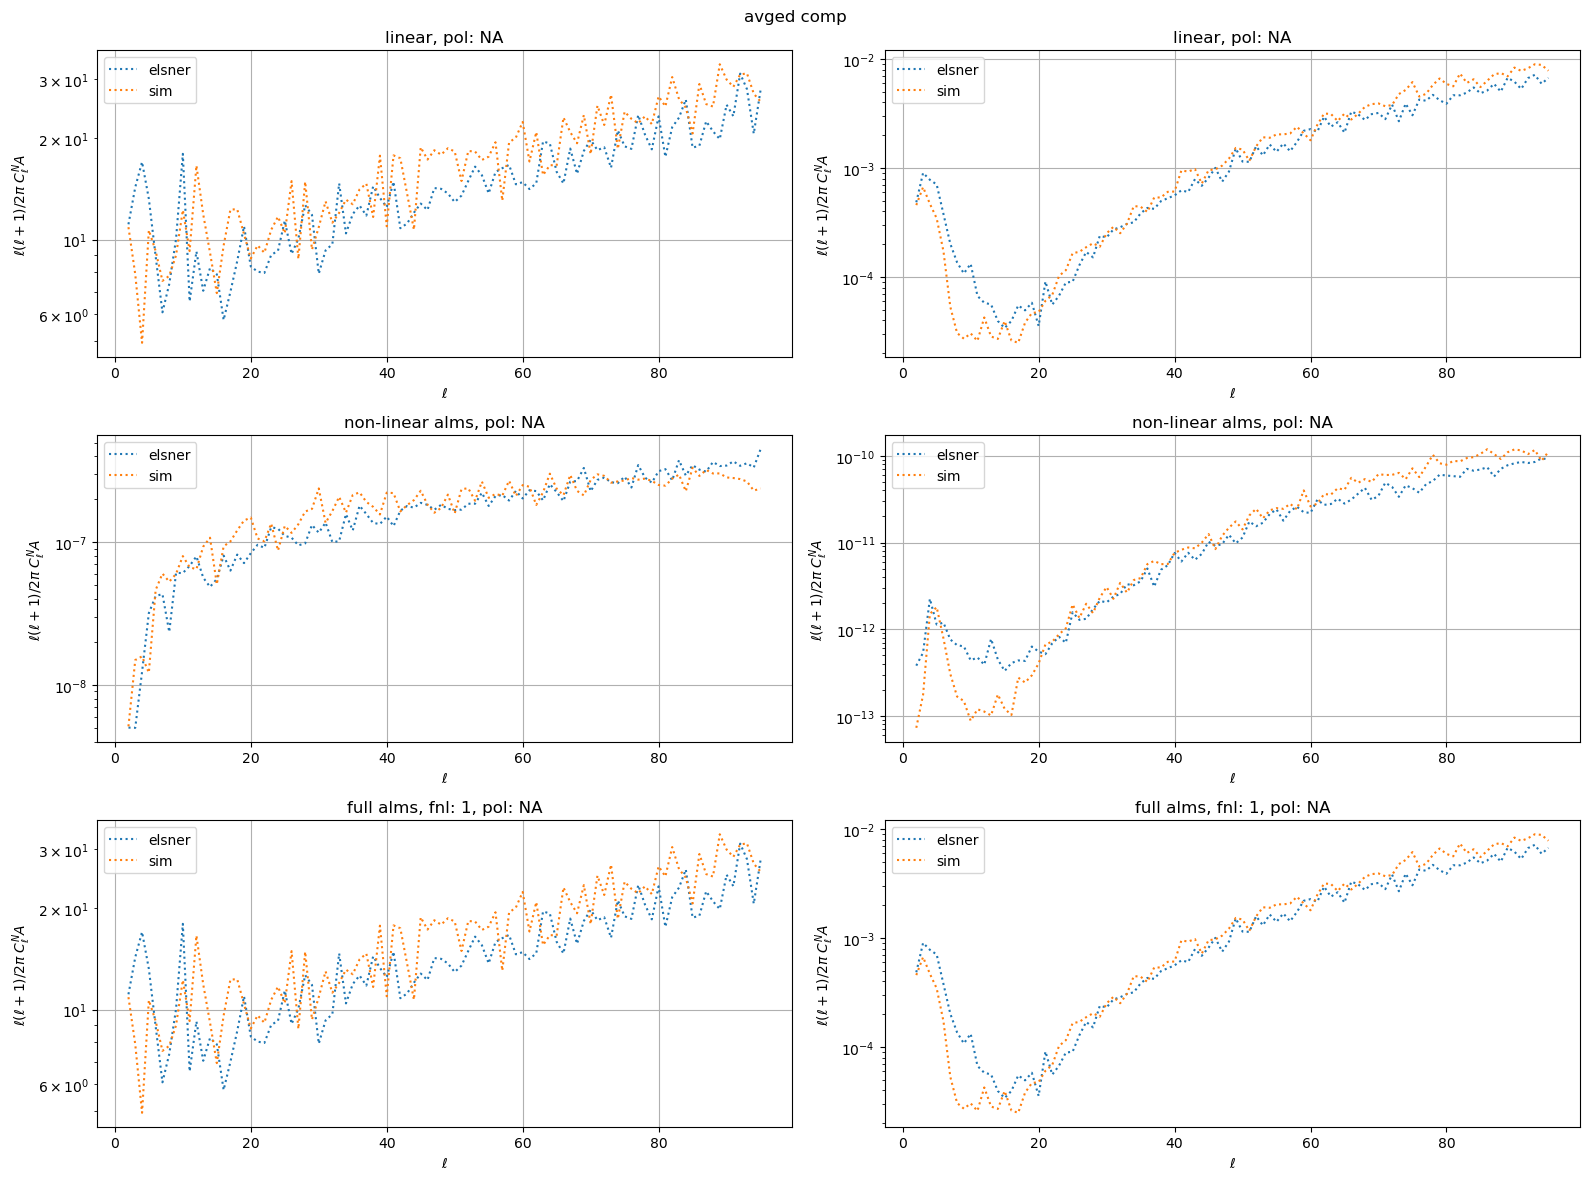

In [90]:
alm_l_avg = np.mean(alm_l[:, core.pol_idxs()], axis=0)
alm_ng_avg = np.mean(alm_ng, axis=0)

plot_elsner_comp(
    core,
    alm_l_avg,
    alm_ng_avg,
    average=core.nsims,
    title="avged comp",
    show=True,
    plot_func=plt.semilogy,
    elsner_pols=core.pol_idxs(),
)

## Estimator

In [91]:
pols = core.pol_idxs()

c_ell = core.c_ell  # if not lensed else core.c_ell_lensed
# cov = core.b_ell**2 * c_ell + core.n_ell
cov = c_ell

ib = np.zeros_like(c_ell)
ib[pols, core.lmin :] = 1 / core.b_ell[pols, core.lmin :]
# n_ell = core.n_ell[pols]
# cov = cov + ib * core.n_ell * ib

ic_ell = np.zeros_like(cov)
ic_ell[pols, core.lmin :] = 1 / cov[pols, core.lmin :]
ic_ell = ic_ell[pols]

fisher = core.estimator.compute_fisher_isotropic(ic_ell, comm=None)
print(f"Fisher: {fisher}, standard deviation: {1 / np.sqrt(fisher)}")

Fisher: 0.0006017019622959197, standard deviation: 40.7670507233677


In [92]:
# from mlpng.core import get_itotcov_ell

# pol = core.pol_idxs()
# # cov = core.b_ell**2 * core.c_ell + core.n_ell  # + core.nb_ell
# cov = core.c_ell
# cov = cov[pols]

# f_ic = np.zeros_like(cov)
# f_ic[..., core.lmin :] = 1 / cov[..., core.lmin :]

# inoise = np.full(cov.shape, 1e-16)
# inoise[..., core.lmin :] = 1 / core.n_ell[pols, core.lmin :]

# f_ic = get_itotcov_ell(f_ic, inoise, core.b_ell[pols])

# logger.debug("Computing Fisher, %s", f_ic.shape)
# fisher = core.estimator.compute_fisher_isotropic(f_ic[pol, pol], comm=mpi_comm)
# print(f"Fisher: {fisher}, standard deviation: {1 / np.sqrt(fisher)}")

In [93]:
fisher = core.estimator.compute_fisher_isotropic(core.icov2, comm=mpi_comm)
print(f"Fisher: {fisher}, standard deviation: {1 / np.sqrt(fisher)}")

Fisher: 0.0005948796169832349, standard deviation: 41.000151821043005


In [94]:
estimates, _, _, _ = core.estimator.compute_estimate_batch(
    lambda idx: core.icov_func(alms[idx, 0]),
    range(core.nsims),
    theta_batch=int(np.floor(1.5 * core.lmax + 1)) // core.n_cpus,
    fisher=fisher,
    lin_term=0,
)

fnl shape (100, 25, 1, 1) estimates shape (100,) fisher 0.0005948796
16-Jan-25 19:10:22 - mlpng.utils.utils - INFO - Standard deviation from fisher: 41.00015095978297, SEM: 4.100015095978297
16-Jan-25 19:10:22 - mlpng.utils.utils - INFO - Mean error: -1.68944524168502, Median error: -6.79701645532765
16-Jan-25 19:10:22 - mlpng.utils.utils - INFO - 53.0% (48.0, 57.99999999999999) are within 1 standard deviations
16-Jan-25 19:10:22 - mlpng.utils.utils - INFO - 84.0% (80.0, 87.0) are within 2 standard deviations
16-Jan-25 19:10:22 - mlpng.utils.utils - INFO - 95.0% (91.0, 98.0) are within 3 standard deviations
16-Jan-25 19:10:22 - mlpng.utils.utils - INFO - 99.0% (99.0, 100.0) are within 4 standard deviations
16-Jan-25 19:10:22 - mlpng.utils.utils - INFO - 100.0% (100.0, 100.0) are within 5 standard deviations


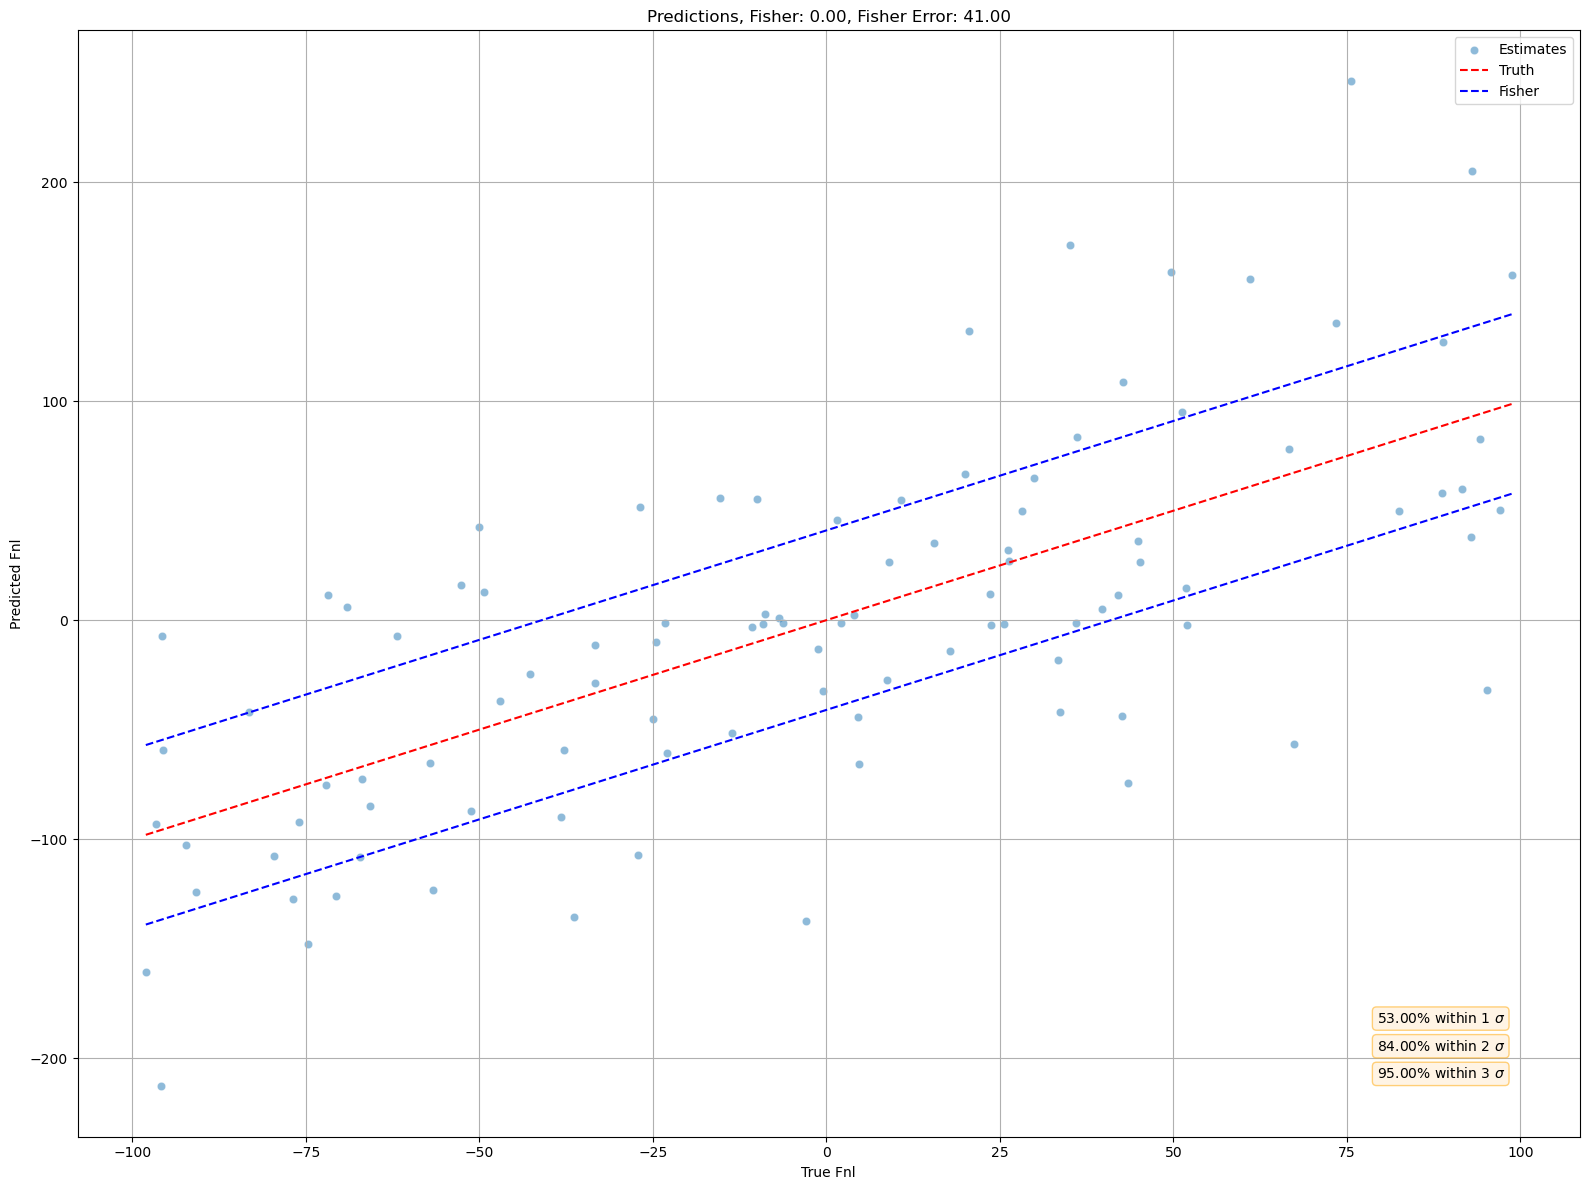

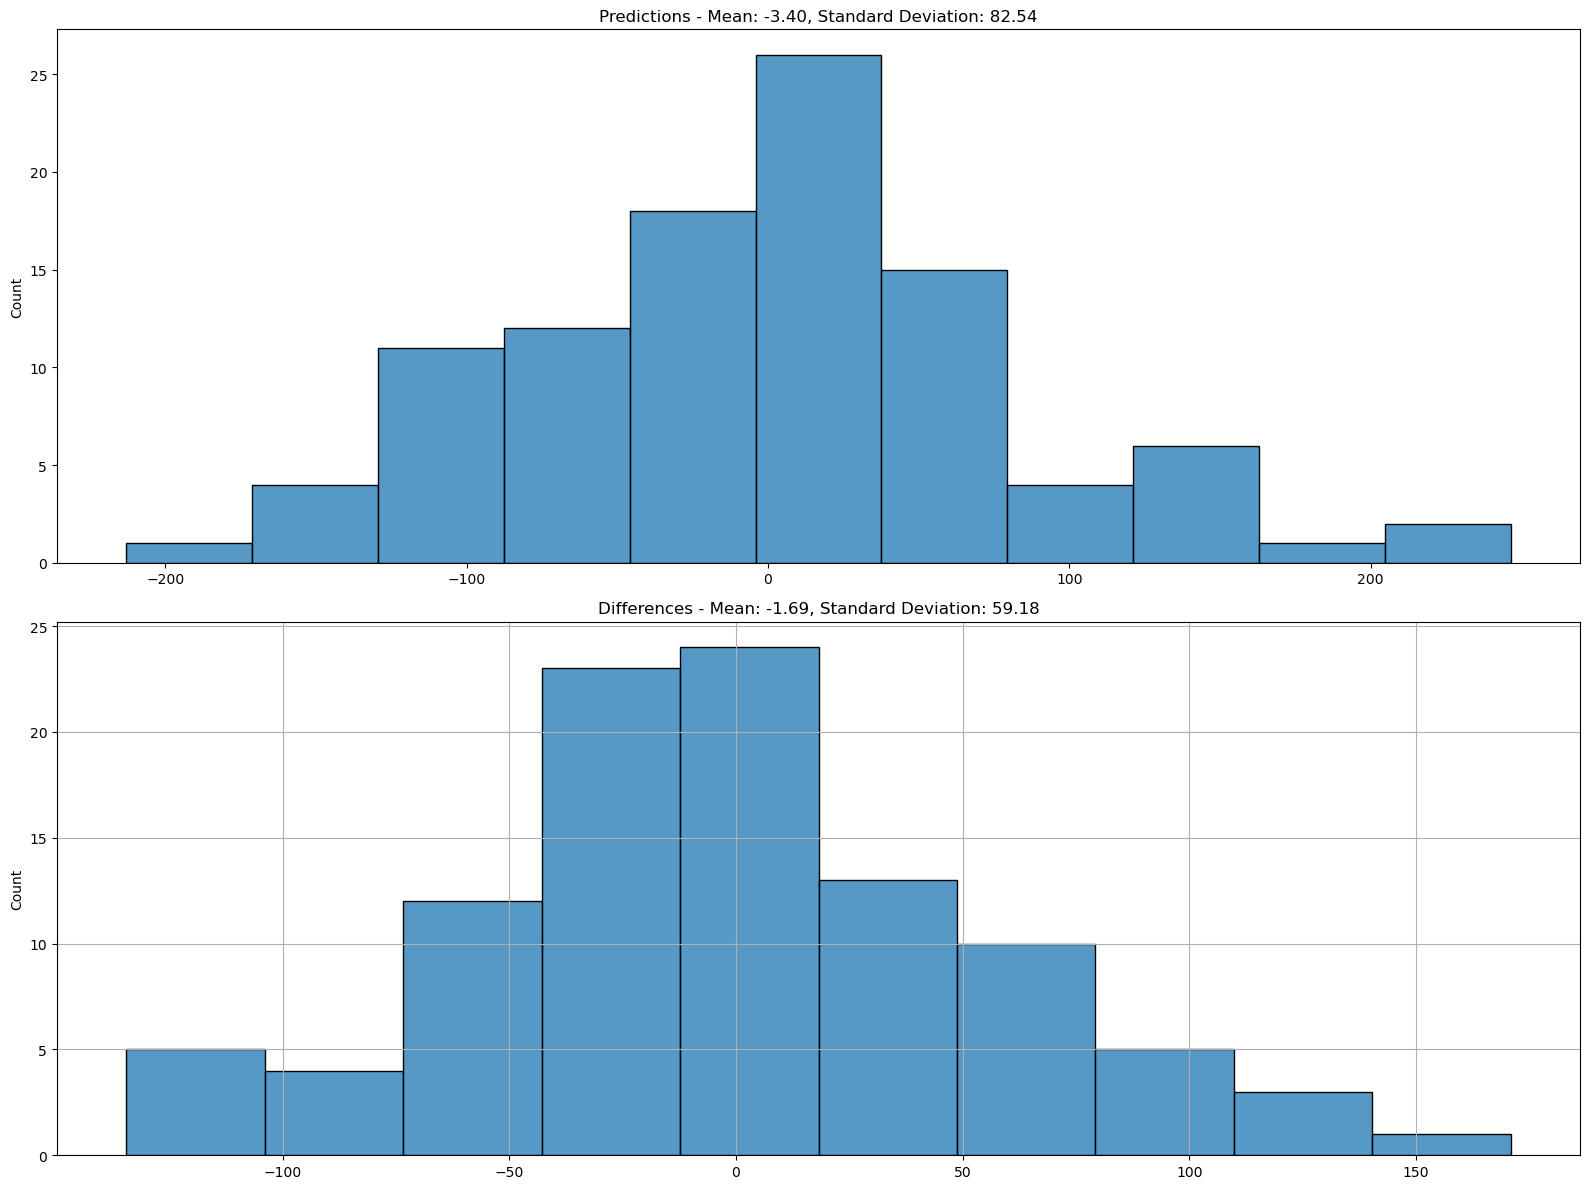

In [95]:
print("fnl shape", fnls.shape, "estimates shape", estimates.shape, "fisher", fisher)
fnls_flat = fnls[:, 0, 0, 0]
print_errors(fnls_flat, estimates, fisher)
plot_predictions(fnls_flat, estimates, fisher=fisher, show=True)
plot_histogram(fnls_flat, estimates, show=True)

## Lensing

In [97]:
alm_lensed, phi_map = lens_alms(core, alms)

16-Jan-25 19:43:38 - mlpng.generator - DEBUG - lens alms shape: (100, 25, 2, 4656)


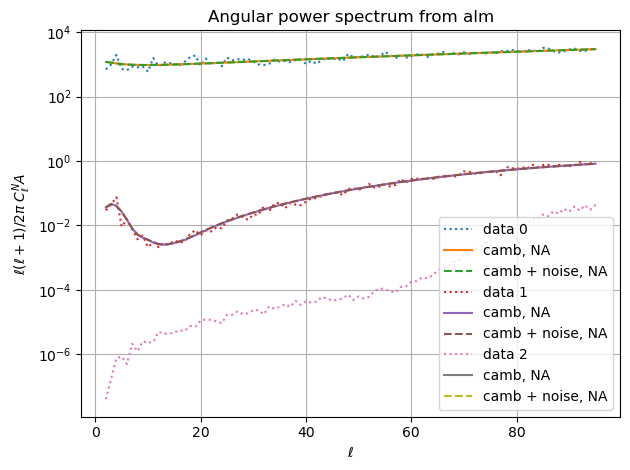

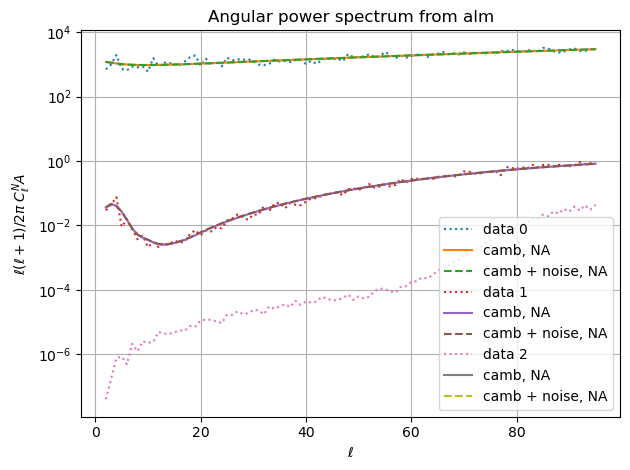

In [98]:
sim = 0
for i, pol in enumerate(core.pol_idxs()):
    pstr = pol_str(pol)

    ylabel = r"$\ell(\ell+1)/2\pi\;C_{\ell}" + f"^{pstr}$"
    plot_cl_alm(
        core,
        alm_lensed[sim, i],
        # save_file=filebase,
        ylabel=ylabel,
        plot_camb=True,
        plot_noise=False,
        plot_full_camb=True,
        show=True,
        lmin=2,
    )

In [99]:
lens_estimates, _, _, _ = core.estimator.compute_estimate_batch(
    lambda a: core.icov_func(alm_lensed[a, 0, core.pol_idxs(pretrimmed=True)]),
    range(core.nsims),
    theta_batch=int(np.floor(1.5 * core.lmax + 1)) // core.n_cpus,
    fisher=fisher,
    lin_term=0,
)

fnl shape (100, 25, 1, 1) estimates shape (100,) fisher 0.0005948796
16-Jan-25 19:44:05 - mlpng.utils.utils - INFO - Standard deviation from fisher: 41.00015095978297, SEM: 4.100015095978297
16-Jan-25 19:44:05 - mlpng.utils.utils - INFO - Mean error: -6.4809757910152825, Median error: -18.067805864444832
16-Jan-25 19:44:05 - mlpng.utils.utils - INFO - 48.0% (45.0, 54.0) are within 1 standard deviations
16-Jan-25 19:44:05 - mlpng.utils.utils - INFO - 82.0% (79.0, 85.0) are within 2 standard deviations
16-Jan-25 19:44:05 - mlpng.utils.utils - INFO - 92.0% (90.0, 94.0) are within 3 standard deviations
16-Jan-25 19:44:05 - mlpng.utils.utils - INFO - 97.0% (95.0, 98.0) are within 4 standard deviations
16-Jan-25 19:44:05 - mlpng.utils.utils - INFO - 99.0% (98.0, 100.0) are within 5 standard deviations


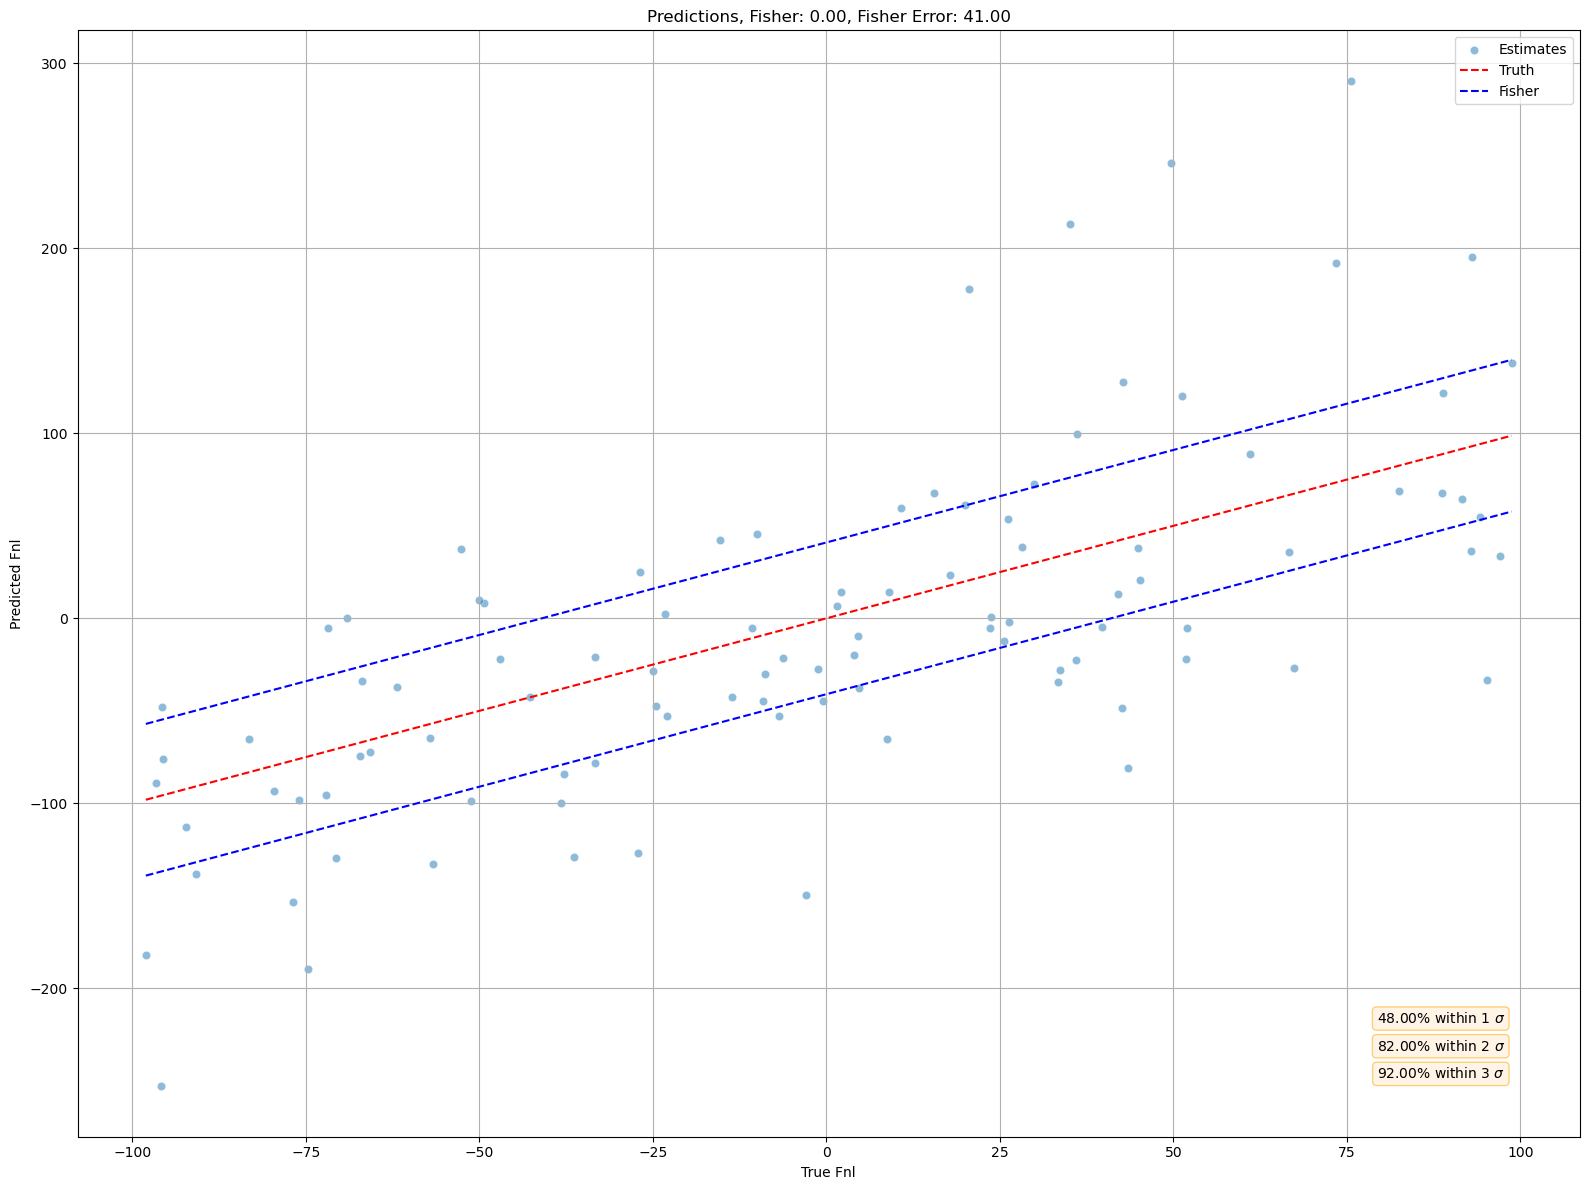

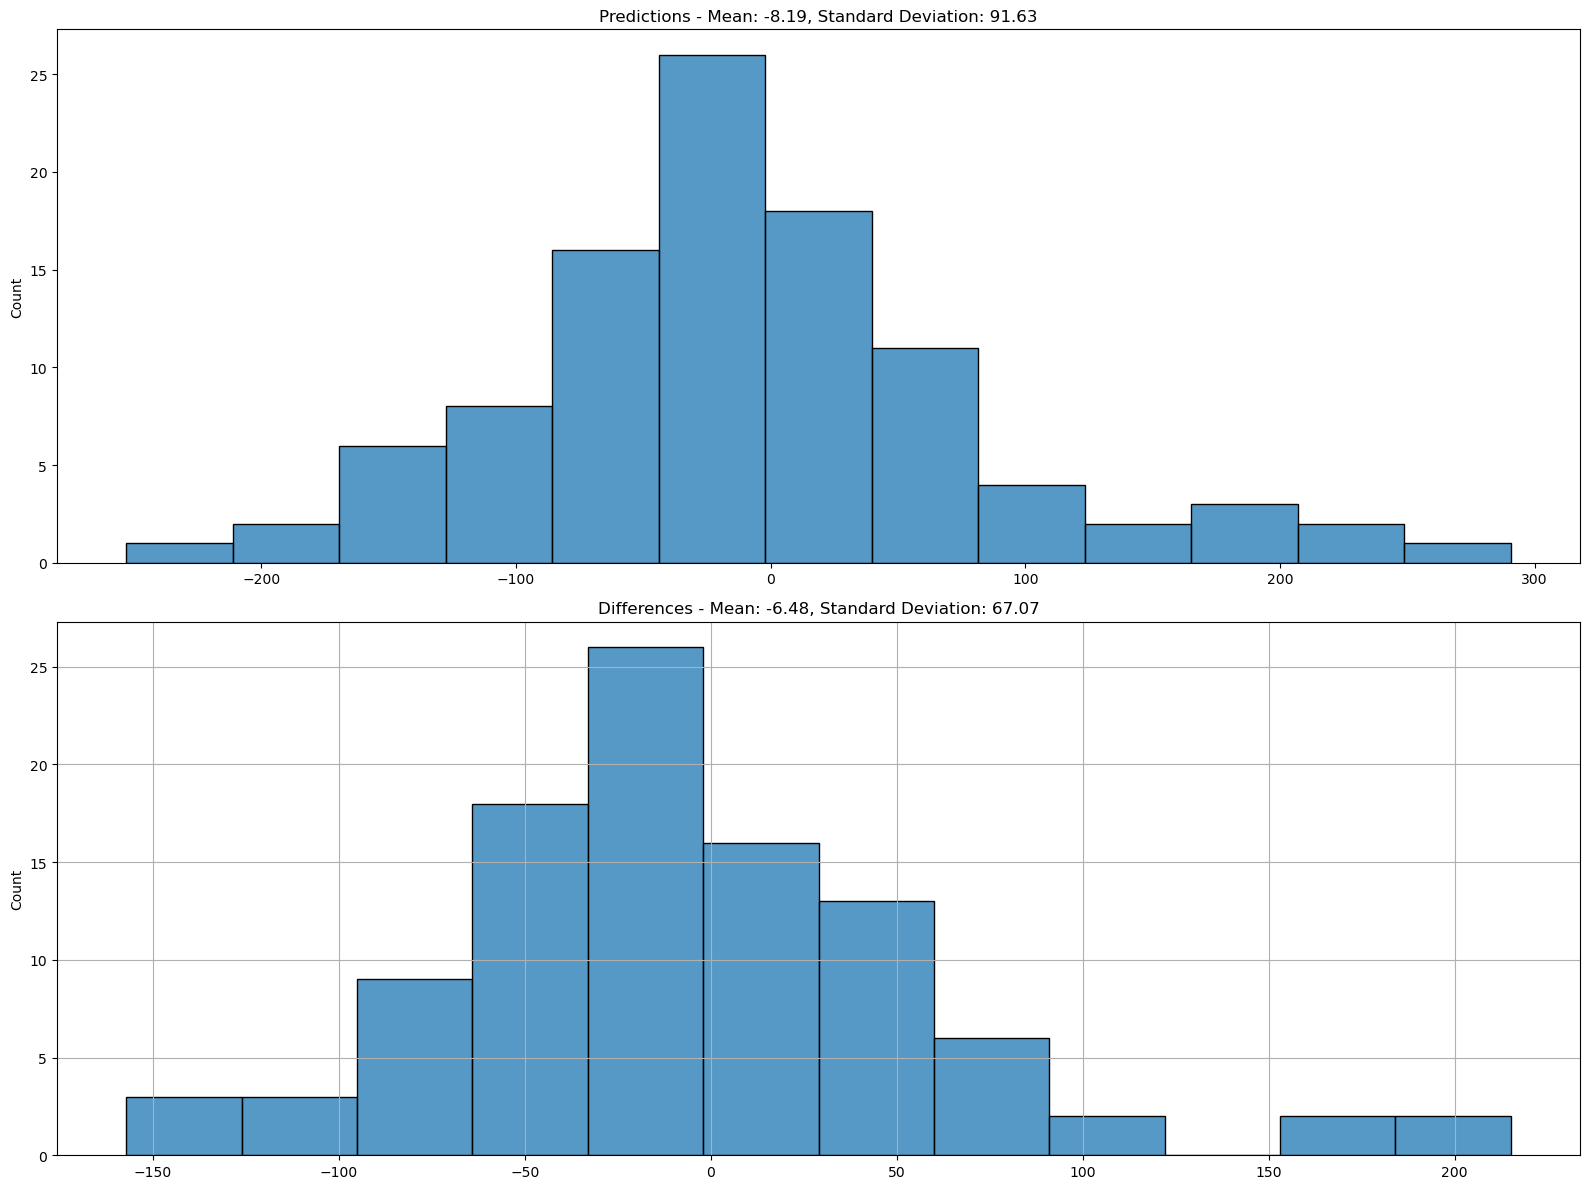

In [100]:
print(
    "fnl shape", fnls.shape, "estimates shape", lens_estimates.shape, "fisher", fisher
)
fnls_flat = fnls[:, 0, 0, 0]
print_errors(fnls_flat, lens_estimates, fisher)
plot_predictions(fnls_flat, lens_estimates, fisher=fisher, show=True)
plot_histogram(fnls_flat, lens_estimates, show=True)